In [1]:
print("hello")

hello


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

Dataset URL: https://www.kaggle.com/datasets/rishikeshkonapure/hr-analytics-prediction
License(s): CC0-1.0
100% 50.1k/50.1k [00:00<00:00, 61.2MB/s]



In [5]:
import zipfile
zip_ref = zipfile.ZipFile("hr-analytics-prediction.zip", 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [7]:
!kaggle datasets download -d mominullptr/fifa-world-cup-2026-dataset

Dataset URL: https://www.kaggle.com/datasets/mominullptr/fifa-world-cup-2026-dataset
License(s): CC0-1.0
100% 79.6k/79.6k [00:00<00:00, 64.7MB/s]



##preprocess + EDA + Feature Selection
#Extraction input and output cols
##Scale the values
##Train the model
##Evaluate the model/model selection
##Deploy the model

In [8]:
import pandas as pd

In [9]:
import numpy as np

In [11]:
df = pd.read_csv('/content/placement.csv')

In [12]:
df


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [13]:
df.head()


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [14]:
df.shape

(100, 4)

In [15]:
df = df.iloc[:,1:]

In [16]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [17]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [19]:
df


,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [20]:
import matplotlib.pyplot as plt

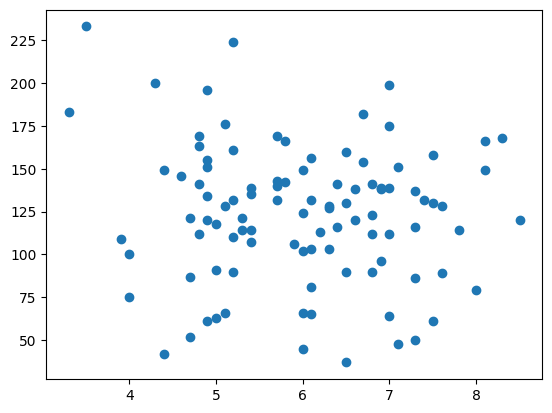

In [21]:
plt.scatter(df['cgpa'], df['iq'])

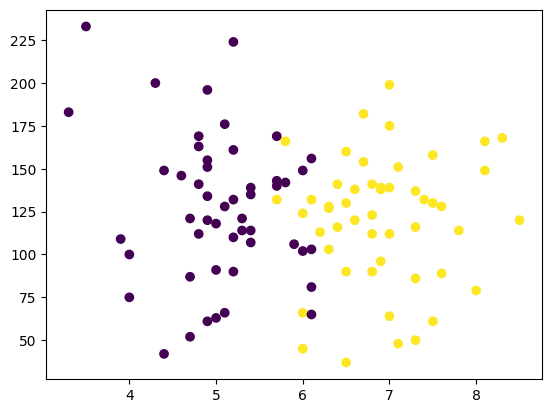

In [23]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [24]:
#logistic regression

In [31]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [32]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [34]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [35]:
y.shape

(100,)

In [38]:
# train test split
from sklearn.model_selection import train_test_split

train_test_split(X,y,test_size=0.1)

[    cgpa     iq
 28   5.2   90.0
 66   6.9   96.0
 7    5.0   63.0
 75   4.8  169.0
 64   7.0   64.0
 ..   ...    ...
 81   5.4  107.0
 92   5.2  110.0
 77   7.3   50.0
 11   6.9  138.0
 19   5.2  132.0
 
 [90 rows x 2 columns],
     cgpa     iq
 55   7.8  114.0
 3    7.4  132.0
 90   7.3   86.0
 31   3.9  109.0
 2    5.3  121.0
 24   4.7  121.0
 79   6.5   90.0
 57   6.5  130.0
 76   4.9  155.0
 37   8.1  149.0,
 28    0
 66    1
 7     0
 75    0
 64    1
      ..
 81    0
 92    0
 77    1
 11    1
 19    0
 Name: placement, Length: 90, dtype: int64,
 55    1
 3     1
 90    1
 31    0
 2     0
 24    0
 79    1
 57    1
 76    0
 37    1
 Name: placement, dtype: int64]

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [40]:
X_train

,cgpa,iq
69,8.5,120.0
77,7.3,50.0
84,5.7,169.0
10,6.0,45.0
49,5.4,135.0
...,...,...
36,5.7,140.0
62,6.0,102.0
1,5.9,106.0
40,4.9,134.0


In [41]:
y_train

,placement
69,1
77,1
84,0
10,1
49,0
...,...
36,0
62,0
1,0
40,0


In [42]:
X_test

,cgpa,iq
25,5.0,91.0
87,5.7,132.0
80,4.9,196.0
56,6.1,65.0
46,5.3,114.0
33,6.0,149.0
97,6.7,182.0
21,7.1,151.0
39,4.6,146.0
67,5.0,118.0


In [43]:
# Now its time to scaling
from sklearn.preprocessing import StandardScaler

In [44]:
scaler = StandardScaler()

In [46]:
X_train = scaler.fit_transform(X_train)

In [47]:
X_train

array([[ 2.12192039, -0.05973906],
       [ 1.09102789, -1.81841242],
       [-0.28349544,  1.17133229],
       [-0.02577231, -1.94403194],
       [-0.54121856,  0.31711951],
       [ 0.66148935, -0.81345622],
       [ 0.83330477, -0.2607303 ],
       [ 0.23195081, -0.48684545],
       [ 1.26284331,  0.19149999],
       [-0.62712627, -0.03461516],
       [ 1.34875102,  0.14125218],
       [ 0.74739706,  0.39249123],
       [ 0.74739706,  0.41761513],
       [-1.05666481,  0.46786294],
       [ 0.31785852,  0.46786294],
       [-1.14257252, -0.88882793],
       [ 1.09102789, -0.16023468],
       [-0.79894169,  1.34719962],
       [ 1.09102789,  0.36736732],
       [-0.9707571 , -1.54204946],
       [-0.71303398,  2.55314706],
       [-1.40029564, -2.01940366],
       [-0.9707571 ,  0.71910199],
       [ 0.66148935,  0.46786294],
       [ 1.52056643, -0.21048249],
       [ 0.0601354 , -0.48684545],
       [-0.28349544,  0.51811075],
       [-0.71303398,  0.97034104],
       [ 1.34875102,

In [48]:
X_test = scaler.transform(X_test)

In [49]:
x_test

NameError: name 'x_test' is not defined

In [50]:
X_test

array([[-0.88484939, -0.78833231],
       [-0.28349544,  0.2417478 ],
       [-0.9707571 ,  1.84967772],
       [ 0.0601354 , -1.44155384],
       [-0.62712627, -0.21048249],
       [-0.02577231,  0.66885418],
       [ 0.57558164,  1.49794305],
       [ 0.91921248,  0.71910199],
       [-1.22848023,  0.59348247],
       [-0.88484939, -0.10998687]])

In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
clf = LogisticRegression()

In [53]:
clf.fit(X_train, y_train)

LogisticRegression()

In [56]:
# model training
clf.fit(X_train,y_train)


LogisticRegression()

In [57]:
clf.predict(X_test)

array([0, 0, 0, 1, 0, 0, 1, 1, 0, 0])

In [58]:
y_test

,placement
25,0
87,1
80,0
56,0
46,0
33,0
97,1
21,1
39,0
67,0


In [60]:
y_pred = clf.predict(X_test)


In [61]:
clf.coef_

array([[ 3.34354846, -0.1931062 ]])

In [62]:
y_pred


array([0, 0, 0, 1, 0, 0, 1, 1, 0, 0])

In [64]:
from sklearn.metrics import accuracy_score

In [65]:
accuracy_score(y_test,y_pred)

0.8

In [66]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

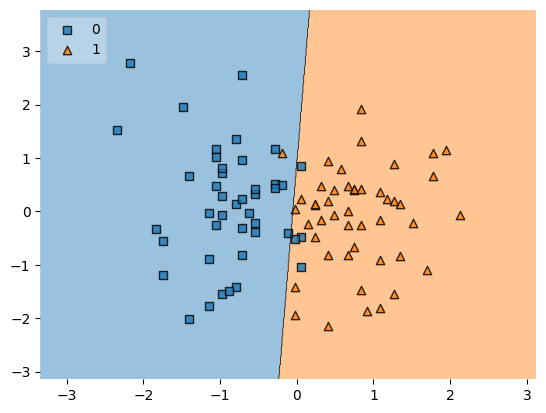

In [67]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [68]:
import pickle

In [69]:
pickle.dump(clf,open('model.pkl','wb'))